# Blinkit Grocery Sales & Customer Insights Analysis

Cleans the Blinkit grocery dataset (8,523 rows x 12 columns), standardizes
inconsistent fields, and produces the KPI aggregations and charts used for
the Power BI dashboard.

**Dataset:** `blinkit_data.csv` — retail/FMCG sales data with item, outlet,
and sales fields.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
%matplotlib inline

## 1. Load the data

In [2]:
RAW_FILE = "blinkit_data.csv"
df = pd.read_csv(RAW_FILE)

print("Shape:", df.shape)
df.head()

Shape: (8523, 12)


,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


## 2. Initial inspection

Check data types, missing values, and messy category labels before cleaning anything.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   str    
 1   Item Identifier            8523 non-null   str    
 2   Item Type                  8523 non-null   str    
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   str    
 5   Outlet Location Type       8523 non-null   str    
 6   Outlet Size                8523 non-null   str    
 7   Outlet Type                8523 non-null   str    
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [4]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [5]:
print("Unique Item Fat Content values:", df["Item Fat Content"].unique())

Unique Item Fat Content values: <StringArray>
['Regular', 'Low Fat', 'low fat', 'LF', 'reg']
Length: 5, dtype: str


## 3. Data cleaning

**Issues found in this dataset:**
- `Item Fat Content` has 5 inconsistent labels (`Regular`, `Low Fat`, `low fat`, `LF`, `reg`) that should collapse to 2
- `Item Weight` has ~1,463 missing values
- `Item Visibility` has 526 rows with a value of exactly 0, which isn't physically meaningful
- `Outlet Size` has no missing values in this file, but a fallback is included in case a refreshed export does

In [6]:
# Standardize Item Fat Content labels
df["Item Fat Content"] = df["Item Fat Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular",
})
df["Item Fat Content"].value_counts()

Item Fat Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [7]:
# Fill missing Item Weight: first by the item's own average weight
# (same product across stores), then by the average for its Item Type
df["Item Weight"] = df.groupby("Item Identifier")["Item Weight"].transform(
    lambda x: x.fillna(x.mean())
)
df["Item Weight"] = df.groupby("Item Type")["Item Weight"].transform(
    lambda x: x.fillna(x.mean())
)

In [8]:
# Fill missing Outlet Size with the most common size for that Outlet Type (safety net)
if df["Outlet Size"].isnull().any():
    mode_by_type = df.groupby("Outlet Type")["Outlet Size"].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    df["Outlet Size"] = df.apply(
        lambda row: mode_by_type[row["Outlet Type"]]
        if pd.isna(row["Outlet Size"])
        else row["Outlet Size"],
        axis=1,
    )

In [9]:
# Treat Item Visibility == 0 as missing, impute with the average for that Item Type
df["Item Visibility"] = df["Item Visibility"].replace(0, np.nan)
df["Item Visibility"] = df.groupby("Item Type")["Item Visibility"].transform(
    lambda x: x.fillna(x.mean())
)

In [10]:
# Derive a helper column: how many years each outlet has been open
current_year = datetime.now().year
df["Outlet Age"] = current_year - df["Outlet Establishment Year"]

In [11]:
# Confirm no missing values remain
df.isnull().sum()

Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Item Weight                  0
Sales                        0
Rating                       0
Outlet Age                   0
dtype: int64

## 4. Export the cleaned dataset

This is the file to import into Power BI — one clean, analysis-ready table.

In [12]:
df.to_csv("blinkit_cleaned.csv", index=False)
print("Saved: blinkit_cleaned.csv")

Saved: blinkit_cleaned.csv


## 5. Headline KPIs

The four numbers that go into the KPI cards at the top of the dashboard.

In [13]:
total_sales = df["Sales"].sum()
avg_sales = df["Sales"].mean()
item_count = df["Item Identifier"].nunique()
avg_rating = df["Rating"].mean()

print(f"Total Sales:    {total_sales:,.0f}")
print(f"Average Sales:  {avg_sales:,.2f}")
print(f"Item Count:     {item_count}")
print(f"Average Rating: {avg_rating:.2f}")

Total Sales:    1,201,681
Average Sales:  140.99
Item Count:     1559
Average Rating: 3.97


## 6. Sales by Fat Content

Item Fat Content
Low Fat    64.6
Regular    35.4
Name: Sales, dtype: float64


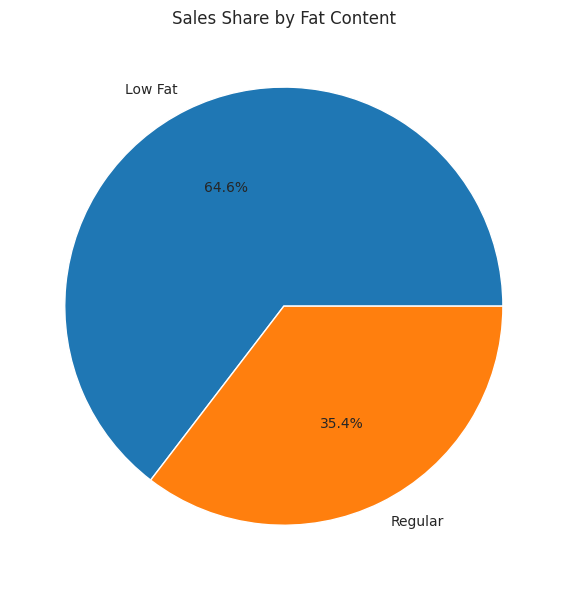

In [14]:
fat_sales = df.groupby("Item Fat Content")["Sales"].sum()
fat_sales_pct = (fat_sales / fat_sales.sum() * 100).round(1)
print(fat_sales_pct)

fat_sales_pct.plot(kind="pie", autopct="%1.1f%%", ylabel="", figsize=(6, 6))
plt.title("Sales Share by Fat Content")
plt.tight_layout()
plt.savefig("sales_by_fat_content.png")
plt.show()

## 7. Sales by Item Type

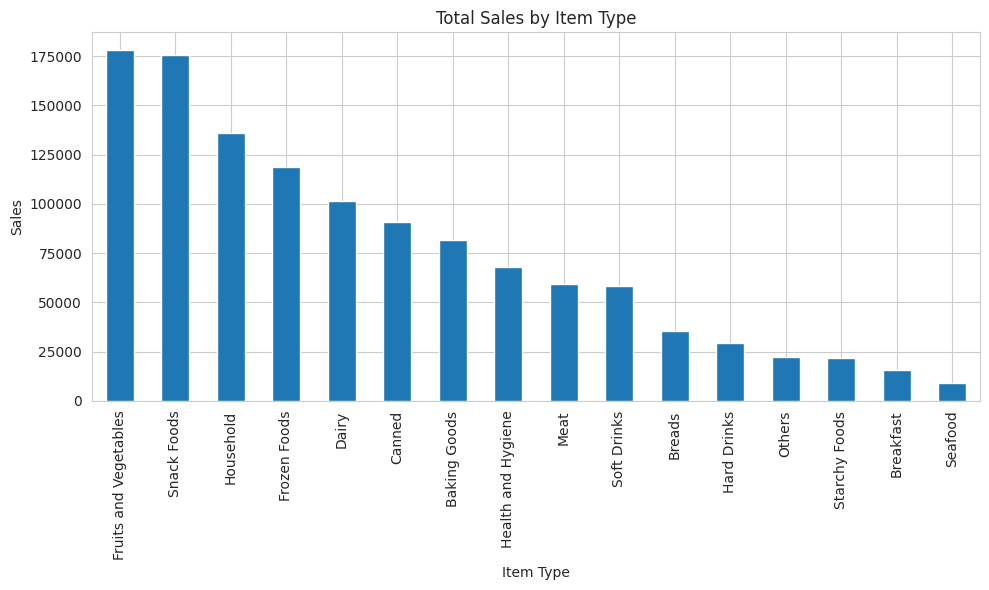

In [15]:
item_type_sales = df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
item_type_sales.plot(kind="bar")
plt.title("Total Sales by Item Type")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("sales_by_item_type.png")
plt.show()

## 8. Sales by Outlet Size, Outlet Type, and City Tier

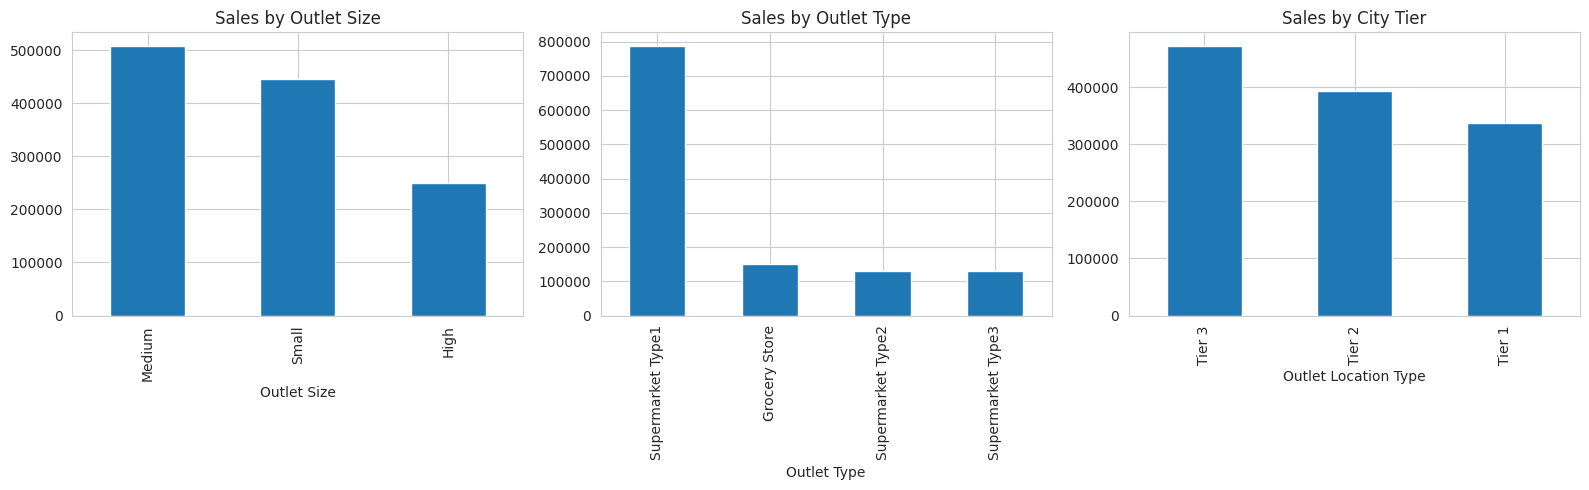

In [16]:
outlet_size_sales = df.groupby("Outlet Size")["Sales"].sum().sort_values(ascending=False)
outlet_type_sales = df.groupby("Outlet Type")["Sales"].sum().sort_values(ascending=False)
city_tier_sales = df.groupby("Outlet Location Type")["Sales"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
outlet_size_sales.plot(kind="bar", ax=axes[0], title="Sales by Outlet Size")
outlet_type_sales.plot(kind="bar", ax=axes[1], title="Sales by Outlet Type")
city_tier_sales.plot(kind="bar", ax=axes[2], title="Sales by City Tier")
plt.tight_layout()
plt.savefig("sales_by_outlet_segments.png")
plt.show()

## 9. Top item types by average rating

In [17]:
top_rated = df.groupby("Item Type")["Rating"].mean().sort_values(ascending=False).head(5)
top_rated

Item Type
Meat                  4.023059
Household             3.998681
Canned                3.994299
Health and Hygiene    3.986154
Baking Goods          3.983025
Name: Rating, dtype: float64

## 10. Correlation between numeric fields

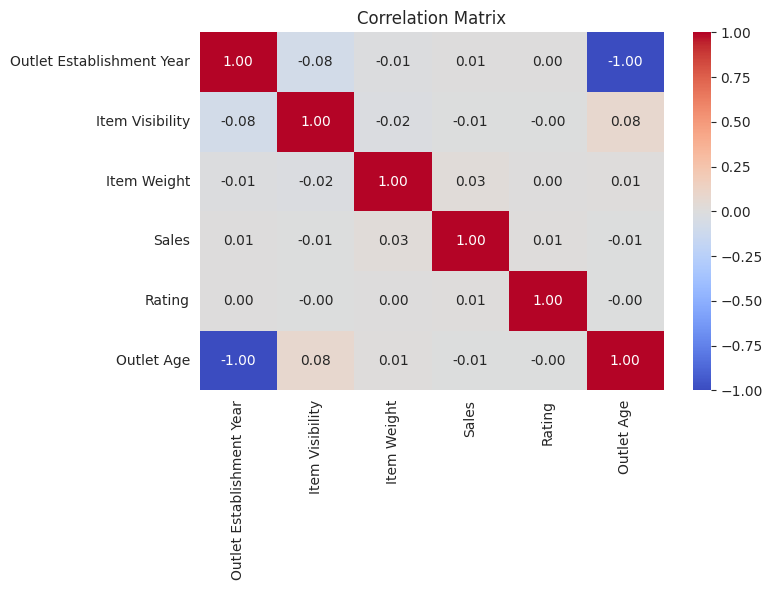

In [18]:
numeric_cols = df.select_dtypes(include=np.number)
corr = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

## Summary of key insights

- **Low Fat items make up ~64.6% of total sales**, Regular ~35.4% — the reverse of the commonly assumed split.
- **Fruits and Vegetables** and **Snack Foods** are the top two item types by sales, each well ahead of the rest.
- **Supermarket Type1** outlets drive the majority of total sales, more than the other three outlet types combined.
- **Medium-sized outlets** outsell Small and High outlets.
- **Tier 3** cities edge out Tier 1 and Tier 2 in total sales.
- Average customer rating is fairly flat across item types (~3.97 overall), with **Meat** slightly ahead at 4.02.